# Stumpy API Overview

A guided walkthrough of the [stumpy](https://stumpy.readthedocs.io/) library
on small synthetic datasets. After this notebook, `stumpy.example.ipynb` uses
the same APIs on real SPY (S&P 500 ETF) market data from 2018 to 2025.

## What is a matrix profile?

Given a time series `T` of length `n` and a subsequence length `m`, the
matrix profile is a vector of length `n - m + 1`. The value at index `i`
is the z-normalized Euclidean distance from the subsequence `T[i : i+m]` to
its nearest non-trivial neighbour elsewhere in `T`.

Two ways to read a matrix profile value `P_i`:

* **Low** P_i: another subsequence in `T` looks very similar to `T[i : i+m]`.
  Repeating patterns are called **motifs**.
* **High** P_i: nothing else in `T` looks like `T[i : i+m]`. Unique patterns
  are called **discords** (anomalies).

This notebook covers the five APIs you will use most:

1. `stumpy.stump`: univariate matrix profile.
2. `stumpy.mstump`: multivariate matrix profile.
3. **LEFT matrix profile**: causal variant for anomaly-onset detection.
4. `stumpy.stumpi`: incremental matrix profile for streaming data.
5. `stumpy.fluss`: regime change-point detection built on top of the matrix
   profile.


## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stumpy

import stumpy_utils as stu

logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

plt.rcParams["figure.figsize"] = (10, 3)
RNG = np.random.default_rng(0)

/Users/skull13/SCHOOL/DATA605/spy-stress-mp/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. `stumpy.stump`: the univariate matrix profile

The simplest API. Given a 1D series and a subsequence length `m`, returns the
matrix profile and the indices of nearest neighbours.

The output is a 2D array with four columns:

| Column | Meaning |
|---|---|
| 0 | Matrix profile distance |
| 1 | Index of nearest neighbour |
| 2 | Index of nearest neighbour to the LEFT (causal) |
| 3 | Index of nearest neighbour to the RIGHT |

We build a synthetic series (a noisy sine wave with one injected square-pulse
anomaly) and verify that `stump` flags it as the top discord.


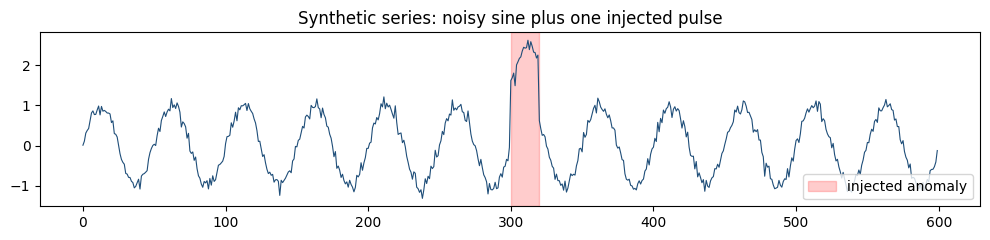

In [2]:
n = 600
m = 30
t = np.arange(n)
y = np.sin(2 * np.pi * t / 50) + 0.1 * RNG.standard_normal(n)

# Inject a square-pulse anomaly in the middle.
anomaly_start, anomaly_len = 300, 20
y[anomaly_start : anomaly_start + anomaly_len] += 1.5

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(t, y, lw=0.8, color="#1f4e79")
ax.axvspan(anomaly_start, anomaly_start + anomaly_len,
           color="red", alpha=0.2, label="injected anomaly")
ax.set_title("Synthetic series: noisy sine plus one injected pulse")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [3]:
mp = stumpy.stump(y, m=m)
print(f"Matrix profile shape: {mp.shape}  (n - m + 1 = {n - m + 1} rows, 4 cols)")

profile = mp[:, 0].astype(float)
discord_idx = int(np.argmax(profile))
print(f"Top discord: subsequence starts at index {discord_idx} "
      f"(injected anomaly starts at {anomaly_start})")

Matrix profile shape: (571, 4)  (n - m + 1 = 571 rows, 4 cols)
Top discord: subsequence starts at index 272 (injected anomaly starts at 300)


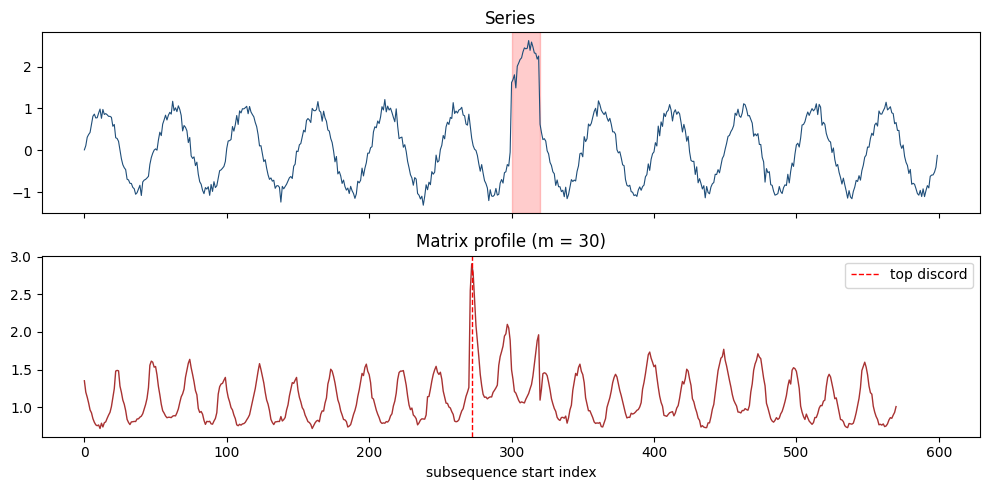

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, y, lw=0.8, color="#1f4e79")
axes[0].axvspan(anomaly_start, anomaly_start + anomaly_len,
                color="red", alpha=0.2)
axes[0].set_title("Series")

axes[1].plot(np.arange(len(profile)), profile, lw=1, color="#a83232")
axes[1].axvline(discord_idx, color="red", ls="--", lw=1, label="top discord")
axes[1].set_title(f"Matrix profile (m = {m})")
axes[1].set_xlabel("subsequence start index")
axes[1].legend()
plt.tight_layout()
plt.show()

### 1.1 Motifs: the lowest matrix profile values

The minimum of the matrix profile is the *most repetitive* subsequence. The
two windows at indices `argmin(profile)` and `mp[argmin, 1]` are the closest
matching pair in the entire series.


Best-matching pair: window @ 11  vs  window @ 160
Distance: 0.7208


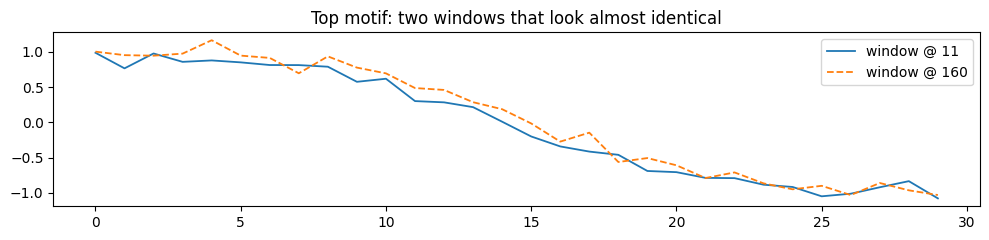

In [5]:
motif_idx = int(np.argmin(profile))
nn_idx = int(mp[motif_idx, 1])
print(f"Best-matching pair: window @ {motif_idx}  vs  window @ {nn_idx}")
print(f"Distance: {profile[motif_idx]:.4f}")

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(y[motif_idx : motif_idx + m], label=f"window @ {motif_idx}", lw=1.3)
ax.plot(y[nn_idx : nn_idx + m],
        label=f"window @ {nn_idx}", lw=1.3, ls="--")
ax.set_title("Top motif: two windows that look almost identical")
ax.legend()
plt.tight_layout()
plt.show()

## 2. `stumpy.mstump`: multivariate matrix profile

`mstump` extends the matrix profile to a panel of `d` time series. The output
`mps` has shape `(d, n - m + 1)`. Row `k` is the matrix profile when at most
`k + 1` of the `d` dimensions are required to match. The bottom row
`mps[-1]` is the **joint** matrix profile: it scores how unusual the
*combination* of all dimensions is.

We build two correlated sine waves and inject a brief joint anomaly: a short
period where both signals jump in the same direction. `mstump` should flag
that joint event with high `mps[-1]`.


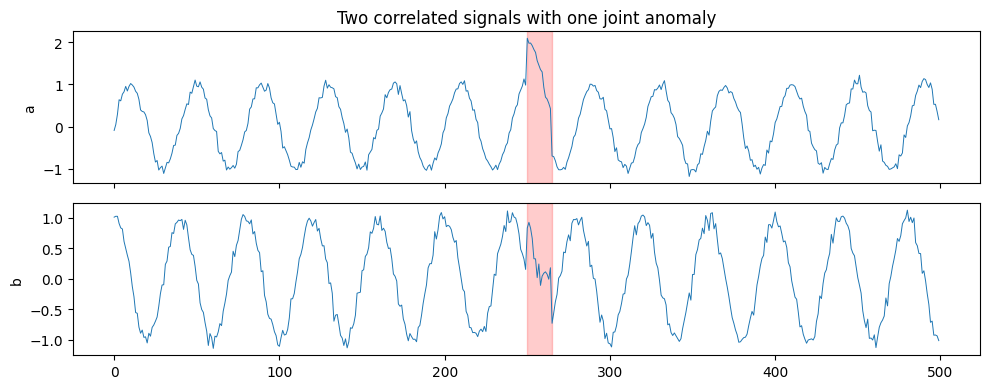

In [6]:
n = 500
m = 30
t = np.arange(n)
a = np.sin(2 * np.pi * t / 40) + 0.08 * RNG.standard_normal(n)
b = np.cos(2 * np.pi * t / 40) + 0.08 * RNG.standard_normal(n)

# Joint anomaly: both signals jump up together for 15 steps.
anomaly_start = 250
a[anomaly_start : anomaly_start + 15] += 1.0
b[anomaly_start : anomaly_start + 15] += 1.0

panel = np.vstack([a, b])  # shape (d=2, n)

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ax, series, name in zip(axes, [a, b], ["a", "b"]):
    ax.plot(t, series, lw=0.7)
    ax.axvspan(anomaly_start, anomaly_start + 15, color="red", alpha=0.2)
    ax.set_ylabel(name)
axes[0].set_title("Two correlated signals with one joint anomaly")
plt.tight_layout()
plt.show()

mps shape: (2, 471)  (d, n - m + 1)
Top JOINT discord starts at index 246 (injected at 250)


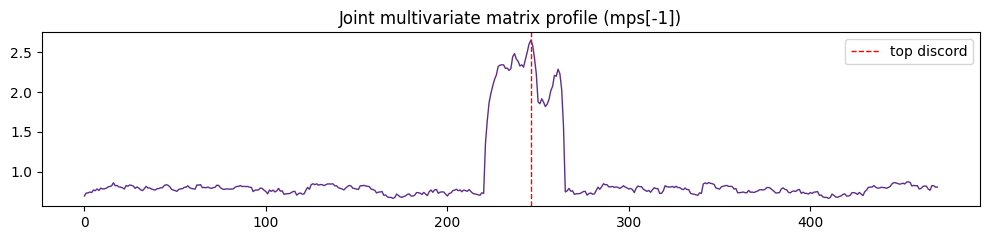

In [7]:
mps, indices = stumpy.mstump(panel, m=m)
print(f"mps shape: {mps.shape}  (d, n - m + 1)")

joint = mps[-1]
joint_discord = int(np.argmax(joint))
print(f"Top JOINT discord starts at index {joint_discord} "
      f"(injected at {anomaly_start})")

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(joint, lw=1, color="#5d2e8c")
ax.axvline(joint_discord, color="red", ls="--", lw=1, label="top discord")
ax.set_title("Joint multivariate matrix profile (mps[-1])")
ax.legend()
plt.tight_layout()
plt.show()

## 3. The LEFT matrix profile (causal anomaly-onset detection)

The standard matrix profile lets each subsequence find its nearest neighbour
**anywhere** in the series, including the future. That is fine for offline
analysis but has two issues:

1. **Not causal**: a value at time `t` can depend on data after `t`, which
   leaks future information into a real-time detector.
2. **Collapses on persistent regimes**: if an anomaly lasts for many
   subsequences, each window finds a near-twin within the same regime, so
   the matrix profile drops to low values inside the regime, the opposite
   of what we want.

The **LEFT matrix profile** restricts the nearest-neighbour search at index
`i` to indices `j < i`. The first occurrence of any pattern then has no past
twin (high LEFT MP), while subsequent occurrences do (low LEFT MP). This is
also strictly causal.

`stumpy.stump` already returns the index of the LEFT nearest neighbour in
column 2. We use the helper `stumpy_utils.left_mp_distance` to convert that
index into the actual z-normalized Euclidean distance.

The toy demonstration below builds a series with two stress regimes. The
standard matrix profile collapses on the second regime; the LEFT matrix
profile correctly flags the onset of both.


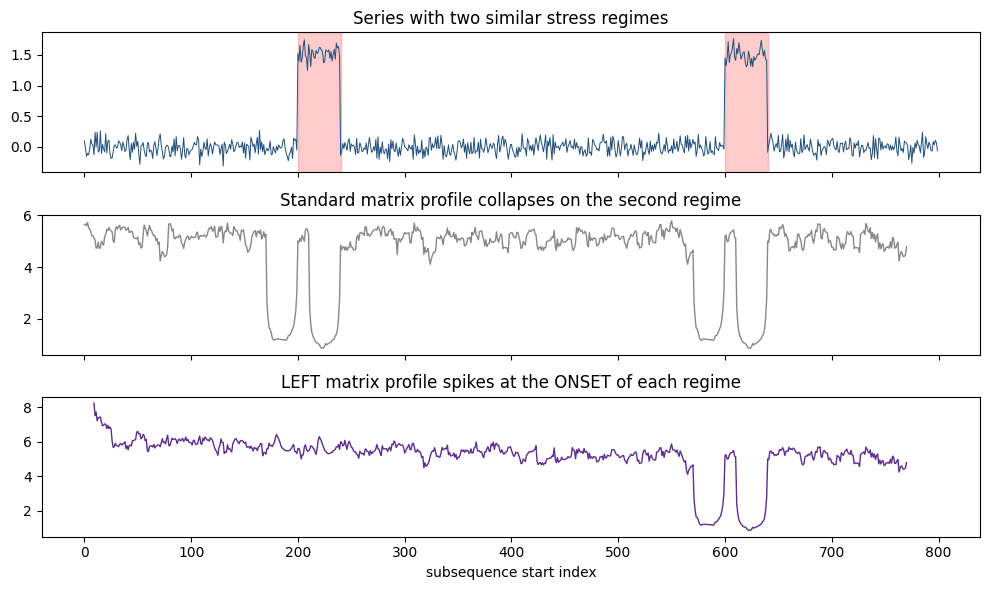

In [8]:
n = 800
m = 30
t = np.arange(n)
y = 0.1 * RNG.standard_normal(n)

# Two stress regimes of similar shape but at different times.
y[200 : 240] += 1.5
y[600 : 640] += 1.5

# Standard self-join MP.
mp_full = stumpy.stump(y, m=m)[:, 0].astype(float)

# Causal LEFT MP via the project helper.
mp_left = stu.left_mp_distance(y, m=m)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t, y, lw=0.7, color="#1f4e79")
for s, e in [(200, 240), (600, 640)]:
    axes[0].axvspan(s, e, color="red", alpha=0.2)
axes[0].set_title("Series with two similar stress regimes")

axes[1].plot(mp_full, lw=1, color="#888")
axes[1].set_title("Standard matrix profile collapses on the second regime")

axes[2].plot(mp_left, lw=1, color="#5d2e8c")
axes[2].set_title("LEFT matrix profile spikes at the ONSET of each regime")
axes[2].set_xlabel("subsequence start index")

plt.tight_layout()
plt.show()

## 4. `stumpy.stumpi`: incremental matrix profile for streaming data

Recomputing the full matrix profile every time a new data point arrives is
wasteful. `stumpy.stumpi` maintains an internal state that lets you append
points one at a time in `O(n)` (amortized).

Typical use:

1. Initialise with the first `n0` historical points.
2. Call `.update(new_value)` for each new arrival.
3. Read `.P_` (the running matrix profile) and `.I_` (nearest-neighbour
   indices) at any time.

This is the right API for live alerting on anomaly onsets in production.


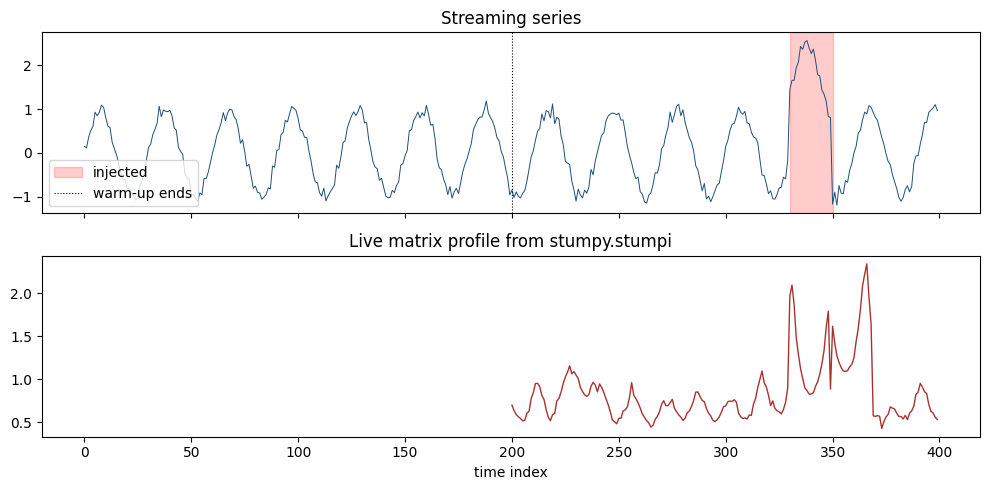

In [9]:
n0 = 200
m = 20
t = np.arange(0, 400)
y = np.sin(2 * np.pi * t / 30) + 0.1 * RNG.standard_normal(len(t))

# Inject an anomaly that appears late in the stream.
y[330:350] += 1.5

# Initialise with the first n0 historical points.
stream = stumpy.stumpi(y[:n0], m=m, egress=False)

# Feed the rest of the stream one point at a time, recording the latest MP value.
mp_live = []
for v in y[n0:]:
    stream.update(v)
    mp_live.append(stream.P_[-1])     # MP value of the latest window

mp_live = np.array(mp_live)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, y, lw=0.7, color="#1f4e79")
axes[0].axvspan(330, 350, color="red", alpha=0.2, label="injected")
axes[0].axvline(n0, color="black", ls=":", lw=0.8, label="warm-up ends")
axes[0].set_title("Streaming series")
axes[0].legend(loc="lower left")

axes[1].plot(np.arange(n0, len(t)), mp_live, lw=1, color="#a83232")
axes[1].set_title("Live matrix profile from stumpy.stumpi")
axes[1].set_xlabel("time index")
plt.tight_layout()
plt.show()

## 5. `stumpy.fluss`: regime change-point detection

The matrix profile carries information about the *direction* in which each
subsequence finds its nearest neighbour. If the data has a structural break,
subsequences after the break tend to point backward to other subsequences
after the break, and vice versa. **FLUSS** (Fast Low-cost Unipotent Semantic
Segmentation) turns that observation into a regime change-point detector.

The output of `stumpy.fluss` is the **CAC** (Corrected Arc Curve). Local
*minima* of the CAC are likely regime boundaries.


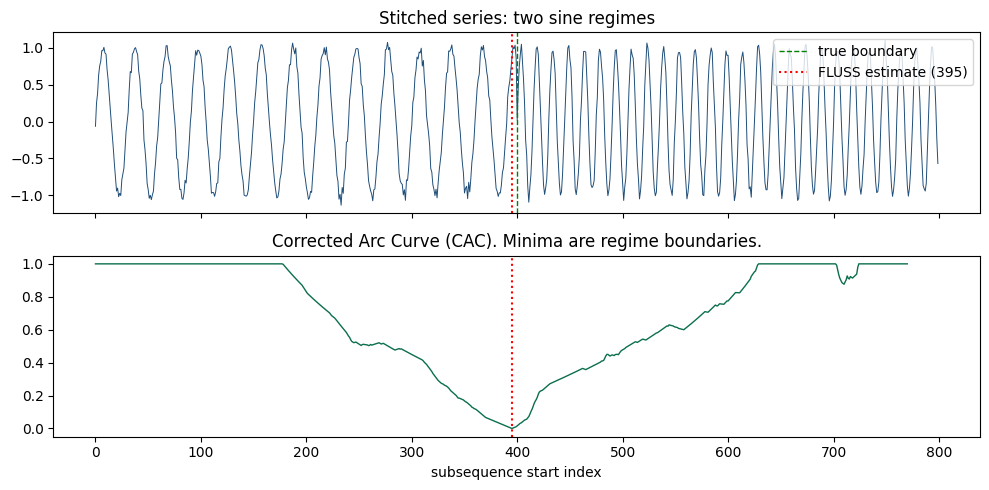

In [10]:
# Two regimes of different periodicity stitched together.
n_per = 400
m = 30
t = np.arange(0, 2 * n_per)
regime_a = np.sin(2 * np.pi * np.arange(n_per) / 30)
regime_b = np.sin(2 * np.pi * np.arange(n_per) / 15)
y = np.concatenate([regime_a, regime_b]) + 0.05 * RNG.standard_normal(2 * n_per)

mp = stumpy.stump(y, m=m)
cac, _ = stumpy.fluss(mp[:, 1], L=m, n_regimes=2, excl_factor=1)

regime_change = int(np.argmin(cac))

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t, y, lw=0.7, color="#1f4e79")
axes[0].axvline(n_per, color="green", ls="--", lw=1, label="true boundary")
axes[0].axvline(regime_change, color="red", ls=":", lw=1.5,
                label=f"FLUSS estimate ({regime_change})")
axes[0].set_title("Stitched series: two sine regimes")
axes[0].legend(loc="upper right")

axes[1].plot(cac, lw=1, color="#0b6e4f")
axes[1].axvline(regime_change, color="red", ls=":", lw=1.5)
axes[1].set_title("Corrected Arc Curve (CAC). Minima are regime boundaries.")
axes[1].set_xlabel("subsequence start index")
plt.tight_layout()
plt.show()

## What to take away

| API | When to use |
|---|---|
| `stumpy.stump` | One time series, find motifs and discords offline. |
| `stumpy.mstump` | Multiple correlated time series, find joint anomalies. |
| LEFT matrix profile | Causal detection, flag the **onset** of new regimes. |
| `stumpy.stumpi` | Streaming data, update the MP one point at a time. |
| `stumpy.fluss` | Find regime boundaries (change points), not point anomalies. |

The application notebook `stumpy.example.ipynb` uses all of these on real
SPY market data to detect periods of market stress.
